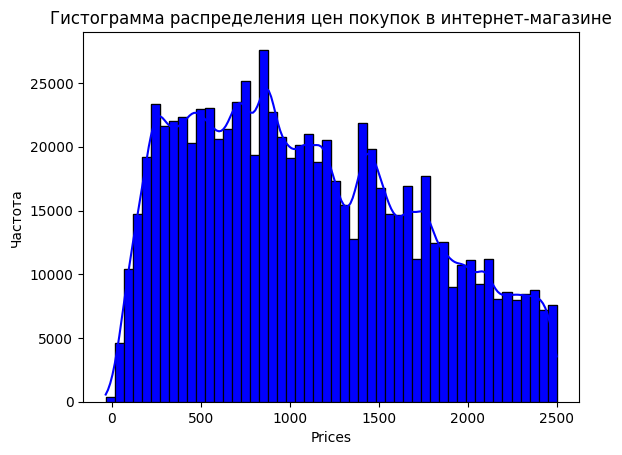

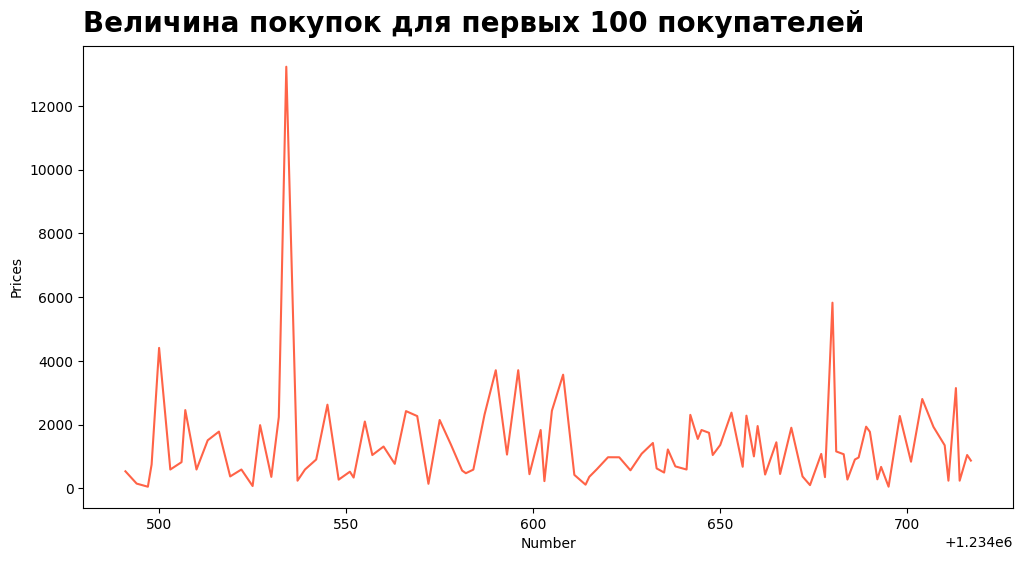

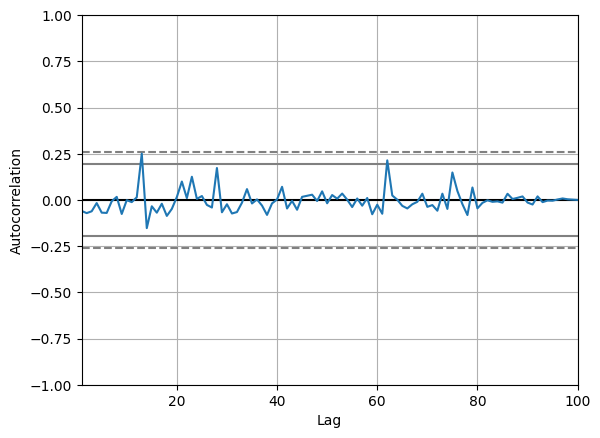

          t-1       t+1
t-1  1.000000 -0.059868
t+1 -0.059868  1.000000


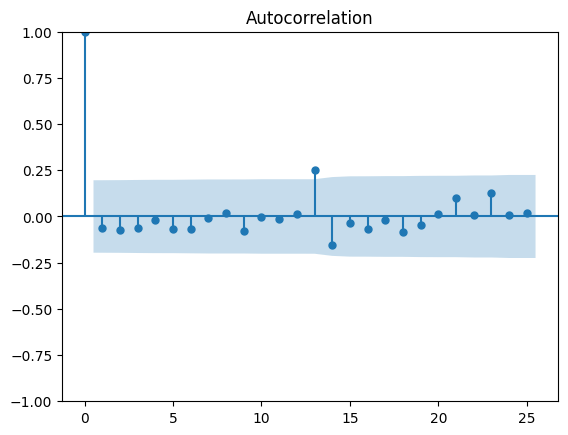

In [3]:
import pandas as pd
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf

from pandas import DataFrame
from pandas import concat

from pandas.plotting import autocorrelation_plot
from matplotlib import pyplot as plt

# 1.
df = pd.read_csv(
    filepath_or_buffer="./Customers.csv",
    sep=";",
    decimal=",",
)

df = df[['Prices', 'Number', 'Customer_id']].astype(float)

df_range = df[df['Prices'] < 2500]

plt.hist(df_range['Prices'], color='blue', edgecolor='black', bins=50)
sns.histplot(df_range['Prices'], kde=True, bins=50, color='blue')
plt.title('Гистограмма распределения цен покупок в интернет-магазине')
plt.xlabel('Prices')
plt.ylabel('Частота')
# plt.show()

# 2.
df = df[:100]
plt.figure(figsize=(12, 6))
plt.plot(df["Number"], df["Prices"], color="tomato")
plt.xlabel("Number")
plt.ylabel("Prices")
plt.yticks()
plt.title("Величина покупок для первых 100 покупателей", loc="left", fontdict=dict(fontsize=20, fontweight="bold"),
          pad=10)
plt.show()

# 3.
autocorrelation_plot(df['Prices'])
plt.show()


"""
Самостоятельная работа.
"""

# 1.

values = DataFrame(df["Prices"].values)
dataframe = concat([values.shift(1), values], axis=1)
dataframe.columns = ['t-1', 't+1']
result = dataframe.corr()
print(result)

# 2.
plot_acf(df["Prices"], lags=25)
plt.show()
